<div style ="background-color :LIGHTBLUE; color:#145A32;padding:15px;border-radius:10px;text-align:center;font-size:20px;"><b>Netflix Data Analysis Project</b></div>

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>IMPORT LIBRARIES</b>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<p style="color:#90EE90;font-size:14px;">We import all the required Python libraries<br>
pandas → for data handling<br>
numpy → for numerical operations<br>
matplotlib / seaborn → for data visualization<br></p>

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>LOAD DATASET</b>
</div>

In [2]:
df = pd.read_csv("netflix_titles.csv", encoding="latin1")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<p style="color:#90EE90;font-size:14px;">Here, we load the dataset to understand th structure<br></p>

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>Data Preprocessing</b>
</div>

In [3]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8807,s8808,TV Show,Parasyte: The Grey,Yeon Sang-ho,"Shin Hyun-been, Jeon Yeo-bin, Goo Kyo-hwan",South Korea,"April 5, 2024",2024,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8808,s8809,Movie,Serena,Susanne Bier,"Bradley Cooper, Jennifer Lawrence, Toby Jones,...",United States,"April 5, 2024",2014,A,110 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<p style="color:#90ee90;font-size:14px;">tail() helps check the ending rows to ensure data is loaded correctly.<br></p>

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   str    
 1   type          8809 non-null   str    
 2   title         8809 non-null   str    
 3   director      6175 non-null   str    
 4   cast          7984 non-null   str    
 5   country       7978 non-null   str    
 6   date_added    8799 non-null   str    
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   str    
 9   duration      8806 non-null   str    
 10  listed_in     8809 non-null   str    
 11  description   8809 non-null   str    
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null      float64
 

<p style="color:#90ee90;font-size:14px;">This step helps identify categorical vs numerical columns and its data types<br></p>

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25'],
      dtype='str')

In [6]:
df.dtypes

show_id             str
type                str
title               str
director            str
cast                str
country             str
date_added          str
release_year      int64
rating              str
duration            str
listed_in           str
description         str
Unnamed: 12     float64
Unnamed: 13     float64
Unnamed: 14     float64
Unnamed: 15     float64
Unnamed: 16     float64
Unnamed: 17     float64
Unnamed: 18     float64
Unnamed: 19     float64
Unnamed: 20     float64
Unnamed: 21     float64
Unnamed: 22     float64
Unnamed: 23     float64
Unnamed: 24     float64
Unnamed: 25     float64
dtype: object

In [7]:
df.shape

(8809, 26)

<p style="color:#90ee90;font-size:14px;">Shows total rows and columns → helps understand dataset size.<br></p>

In [8]:
df.describe()

,release_year,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,8809.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2014.181292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,8.818932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1925.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2019.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2024.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<p style="color:#90ee90;font-size:14px;">It generates the summary statistics for all numerical columns in the dataset.<br></p>

<div style="background-color:#e8f8f5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>Remove Unnecessary Columns</b>
</div>

In [9]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [10]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

<div style="background-color:#e8f8f5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>Missing Values Check</b>
</div>

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

<p style="color:#90ee90;font-size:14px;">It shows total missing values for every column , in this data there is no missing values<br></p>

In [12]:
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df['rating'].fillna("Unknown", inplace=True)

C:\Users\dhanu\AppData\Local\Temp\ipykernel_23120\2131310473.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna("Unknown", inplace=True)
C:\Users\dhanu\AppData\Local\Temp\ipykernel_23120\2131310473.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8804        R
8805       PG
8806    TV-14
8807    TV-MA
8808        A
Name: rating, Length: 8809, dtype: str

<div style="background-color:#e8f8f5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>DATA VISUALIZATION (EDA PLOTS)</b>
</div>

COUNT PLOT

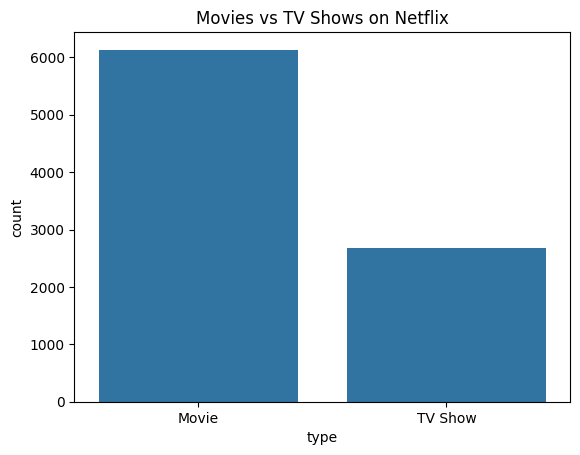

In [13]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

<p style="color:#90ee90;font-size:14px;">It shows movies vs tv shows<br></p>

BAR PLOT

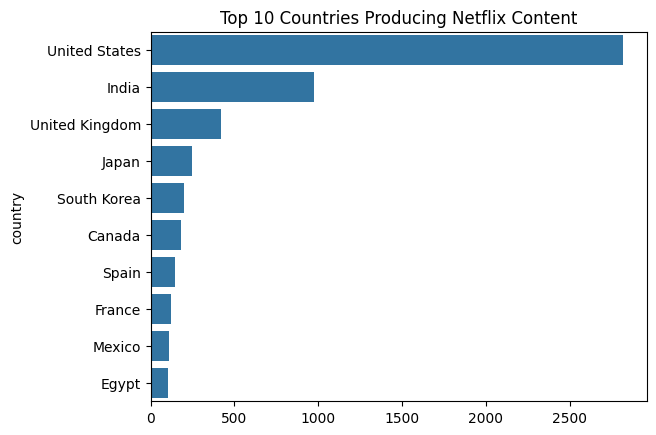

In [14]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Netflix Content")
plt.show()

<p style="color:#90ee90;font-size:14px;">It shows top 10 countries producing content<br></p>

Histogram

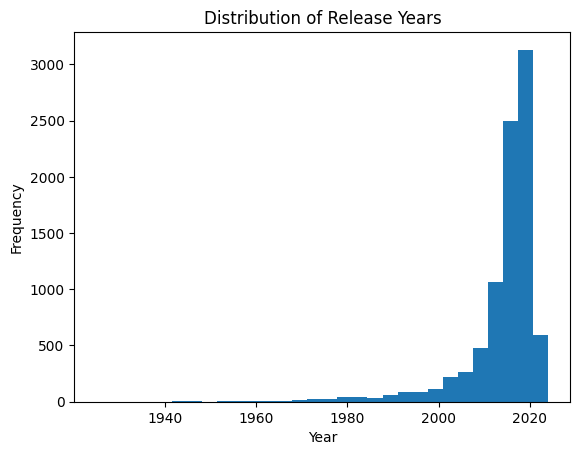

In [15]:
plt.hist(df['release_year'], bins=30)

plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

<p style="color:#90ee90;font-size:14px;">It shows release year distribution<br></p>

PIE CHART

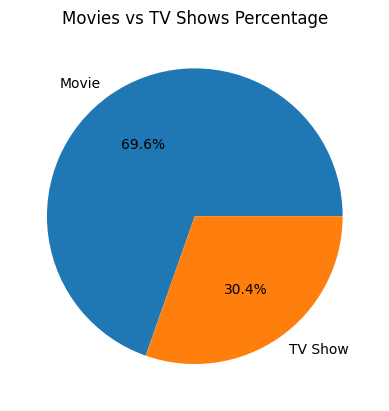

In [16]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')

plt.title("Movies vs TV Shows Percentage")
plt.ylabel("")
plt.show()

<p style="color:#90ee90;font-size:14px;">It shows movies vs tv shows<br></p>

BOX PLOT

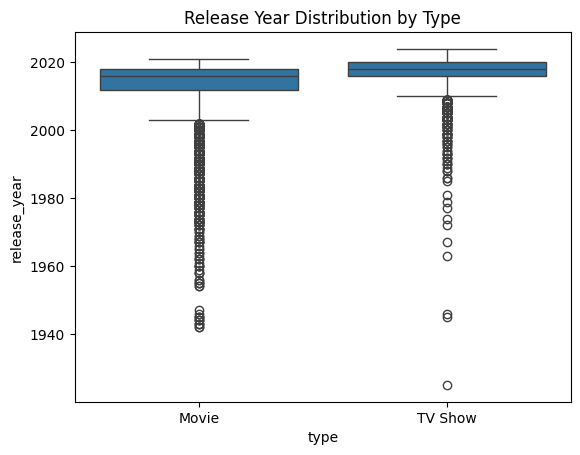

In [17]:
sns.boxplot(x='type', y='release_year', data=df)

plt.title("Release Year Distribution by Type")
plt.show()

<p style="color:#90ee90;font-size:14px;">It shows release year vs type<br></p>

SCATTER PLOT

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\dhanu\AppData\Local\Temp\ipykernel_23120\2985758493.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['duration'] = df['duration'].str.extract('(\d+)')


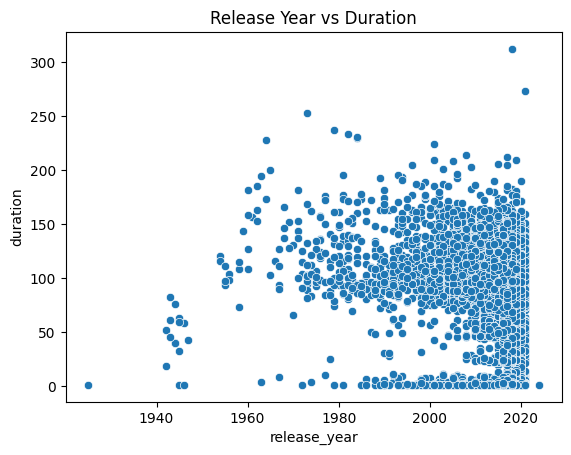

In [18]:
df['duration'] = df['duration'].str.extract('(\d+)')
df['duration'] = df['duration'].astype(float)

sns.scatterplot(x='release_year', y='duration', data=df)

plt.title("Release Year vs Duration")
plt.show()

<p style="color:#90ee90;font-size:14px;">It shows release year vs duration (after cleaning duration)<br></p>

HEAT MAP

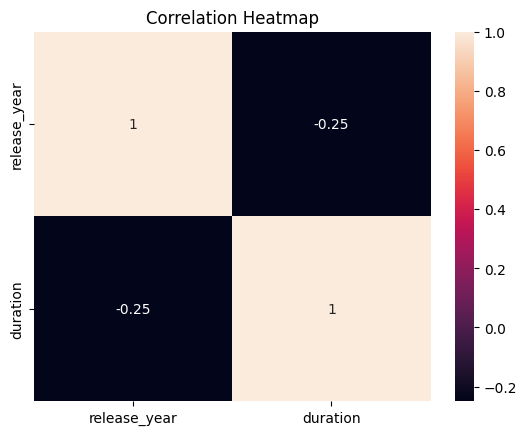

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")
plt.show()

VIOLIN PLOT

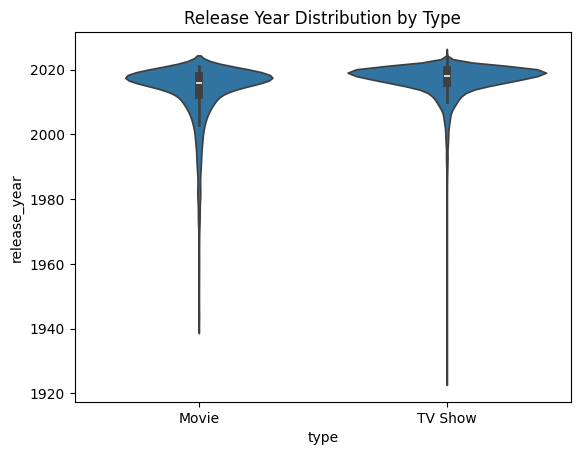

In [20]:
sns.violinplot(x='type', y='release_year', data=df)

plt.title("Release Year Distribution by Type")
plt.show()

PAIR PLOT

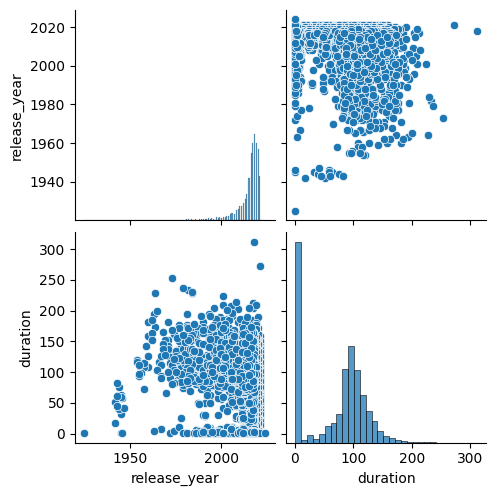

In [21]:
sns.pairplot(df[['release_year','duration']])
plt.show()

SWARM PLOT

c:\Users\dhanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 84.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\dhanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 82.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\dhanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 89.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\dhanu\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 88.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

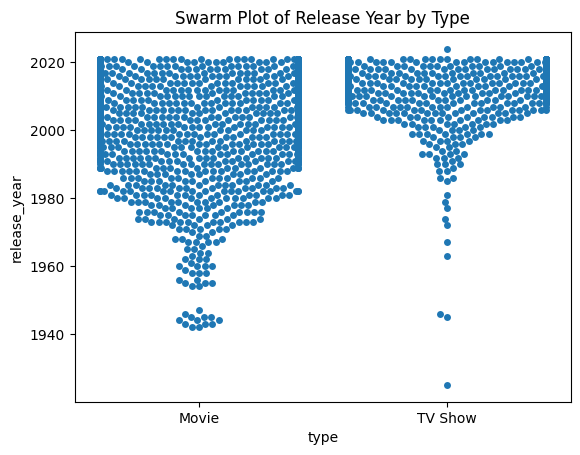

In [22]:
sns.swarmplot(x='type', y='release_year', data=df)
plt.title("Swarm Plot of Release Year by Type")
plt.show()

KDE PLOT

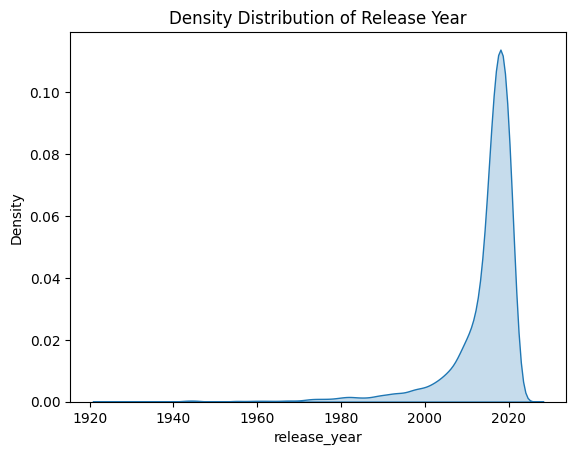

In [23]:
sns.kdeplot(df['release_year'], fill=True)
plt.title("Density Distribution of Release Year")
plt.show()

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>KEY INSIGHTS</b>
</div>

1️⃣ MOVIES VS TV SHOWS

    *The analysis shows that Movies are more common than TV Shows on Netflix.

    *This indicates that Netflix focuses more on movie content than series.

2️⃣ TOP PRODUCING COUNTRIES

     *The United States produces the highest number of Netflix titles.

     *Other major contributors include India, United Kingdom, and Canada.

     *This shows Netflix relies heavily on content from these countries.

3️⃣ CONTENT GROWTH OVER YEARS

     *Netflix content production increased significantly after 2015.

     *This reflects Netflix's rapid global expansion and increased investment in original content.

4️⃣ RATING DISTRIBUTION

     *Most Netflix titles are rated TV-MA and TV-14.

     *This suggests that Netflix mainly targets teen and adult audiences.

5️⃣ DURATION ANALYSIS

     *Most movies have a duration between 80–120 minutes.

     *TV Shows typically have multiple seasons, indicating long-term content engagement.

6️⃣ GENRE POPULARITY

    *The most common genres on Netflix include:

       1.Drama

       2.International Movies

       3.Comedy

    *This shows that Netflix prioritizes globally appealing genres.

7️⃣ GLOBAL CONTENT STRATEGY

     *The dataset shows content from many countries worldwide, indicating Netflix’s focus on global audience reach.

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>SQL Analysis (SQLite)</b>
</div>

In [24]:
import sqlite3
import pandas as pd

In [25]:
conn = sqlite3.connect("netflix.db")

In [26]:
df.to_sql("netflix", conn, if_exists="replace", index=False)

8809

In [27]:
query = """
SELECT type, COUNT(*) as total
FROM netflix
GROUP BY type
"""

In [28]:
pd.read_sql(query, conn)

,type,total
0,Movie,6132
1,TV Show,2677


In [29]:
query = """
SELECT type, COUNT(*) as total
FROM netflix
GROUP BY type
"""

pd.read_sql(query, conn)

,type,total
0,Movie,6132
1,TV Show,2677


In [30]:
query = """
SELECT country, COUNT(*) as total
FROM netflix
GROUP BY country
ORDER BY total DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,country,total
0,United States,2819
1,India,972
2,NaN,831
3,United Kingdom,419
4,Japan,245
5,South Korea,200
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


In [31]:
query = """
SELECT release_year, COUNT(*) as total
FROM netflix
GROUP BY release_year
ORDER BY release_year
"""

pd.read_sql(query, conn)

,release_year,total
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
...,...,...
70,2018,1147
71,2019,1030
72,2020,953
73,2021,592


In [32]:
conn.close()

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>SQL INSIGHTS</b>
</div>

     *Movies dominate the Netflix catalog compared to TV Shows.

     *The United States contributes the highest number of titles.

     *Most Netflix content is rated TV-MA, indicating mature audience targeting.

     *Netflix content increased significantly after 2015, showing rapid platform growth.

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>CONCLUSION</b>
</div>

The analysis of the Netflix dataset reveals that the platform contains a larger number of movies than TV shows, with the United States being the leading content producer. Netflix experienced rapid content growth after 2015 as the platform expanded globally. The majority of titles are targeted toward mature audiences, and popular genres such as drama and international movies dominate the catalog. These trends highlight Netflix’s strategy of expanding global content while focusing on diverse entertainment options.

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>RECOMMENDATIONS</b>
</div>

Netflix can invest more in TV shows since series increase user engagement.

Expanding content production in emerging countries could increase global audience reach.

Adding more family-friendly content could attract a broader viewer base.

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>FUTURE WORK</b>
</div>

Build a Netflix recommendation system using machine learning.

Perform sentiment analysis on movie reviews.

Analyze user viewing patterns to understand content popularity.

<div style="background-color:#E8F8F5;color:black;padding:8px;text-align:center;font-size:18px;border-radius:8px;">
<b>PROJECT LIMITATIONS</b>
</div>

Some fields contain missing or incomplete data.

The dataset may not include all Netflix titles.

Genre categories may overlap between multiple types.